In [ ]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-cb8uq9gw
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-cb8uq9gw
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# Download Full Dataset

Market-1501 dataset :
https://www.kaggle.com/pengcw1/market-1501

In [ ]:
!git clone https://github.com/parth1620/Person-Re-Id-Dataset

Cloning into 'Person-Re-Id-Dataset'...
remote: Enumerating objects: 12942, done.
remote: Counting objects: 100% (12942/12942), done.
remote: Compressing objects: 100% (12942/12942), done.
remote: Total 12942 (delta 0), reused 12942 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12942/12942), 27.68 MiB | 26.74 MiB/s, done.


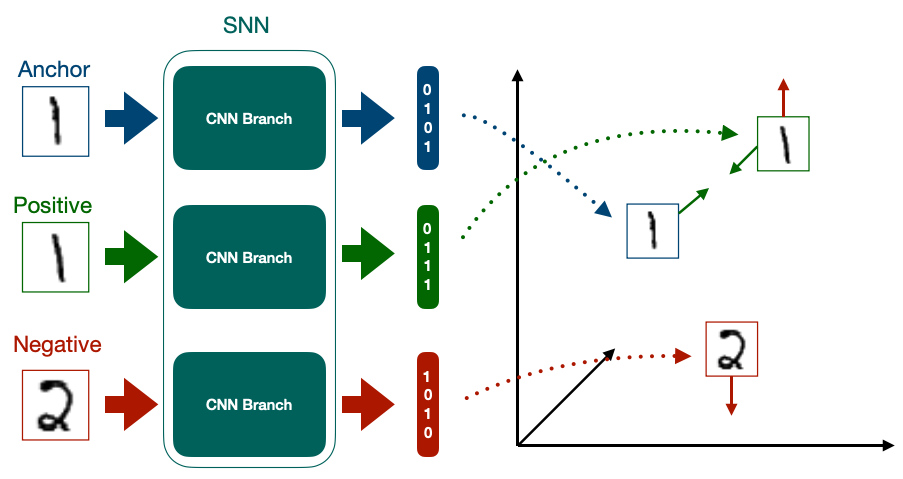

# Imports

In [ ]:
import sys
sys.path.append('/content/Person-Re-Id-Dataset')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

from skimage import io
from sklearn.model_selection import train_test_split

from tqdm import tqdm

# Configurations

In [ ]:
data_dir = '/content/Person-Re-Id-Dataset/train/'
csv_file = '/content/Person-Re-Id-Dataset/train.csv'

batch_size = 32
lr = 0.001
epochs = 15
device = 'cuda'

In [ ]:
df = pd.read_csv(csv_file)
df.head()

,Anchor,Negative,Positive
0,1420_c5s3_052165_01.jpg,1334_c6s3_061492_05.jpg,1420_c3s3_051678_01.jpg
1,1420_c3s3_061978_03.jpg,0234_c3s3_079494_02.jpg,1420_c6s3_085567_02.jpg
2,1420_c5s3_062565_05.jpg,0475_c2s1_122816_08.jpg,1420_c3s3_051653_01.jpg
3,1420_c6s3_085592_04.jpg,0662_c2s2_036662_05.jpg,1420_c1s6_013446_04.jpg
4,0663_c5s3_085987_03.jpg,1463_c2s3_098102_02.jpg,0663_c3s3_085544_06.jpg


In [ ]:
row = df.iloc[21]

A_img = io.imread(data_dir + row.Anchor)
P_img = io.imread(data_dir + row.Positive)
N_img = io.imread(data_dir + row.Negative)


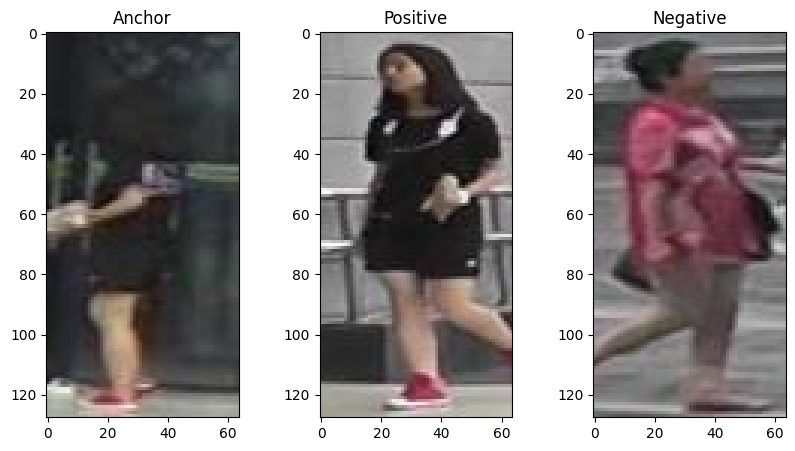

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1,3,figsize= (10,5))

ax1.set_title('Anchor')
ax1.imshow(A_img)

ax2.set_title('Positive')
ax2.imshow(P_img)

ax3.set_title('Negative')
ax3.imshow(N_img)

In [ ]:
train_df, valid_df = train_test_split(df, test_size = 0.20, random_state = 42)

# Create APN Dataset
# A - Anchor,  P - Positive, N - Negative


In [ ]:
from typing import Self
# Custom dataset acc. to the given index
class APN_dataset(Dataset):
  def __init__(self,df):
    self.df = df

  def __len__(self): # length
    return len(self.df)

  def __getitem__(self,idx): # get the item index wise

    row = self.df.iloc[idx]

    A_img = io.imread(data_dir + row.Anchor)
    P_img = io.imread(data_dir + row.Positive)
    N_img = io.imread(data_dir + row.Negative)


    # Converting images to torch
    A_img = torch.from_numpy(A_img).permute(2,0,1) / 255.0
    P_img = torch.from_numpy(P_img).permute(2,0,1) / 255.0
    N_img = torch.from_numpy(N_img).permute(2,0,1) / 255.0

    return A_img, P_img, N_img

In [ ]:
trainset = APN_dataset(train_df)
validset = APN_dataset(valid_df)

print(f"Size of trainset: {len(trainset)}")
print(f"Size of validset: {len(validset)}")

Size of trainset: 3200
Size of validset: 800


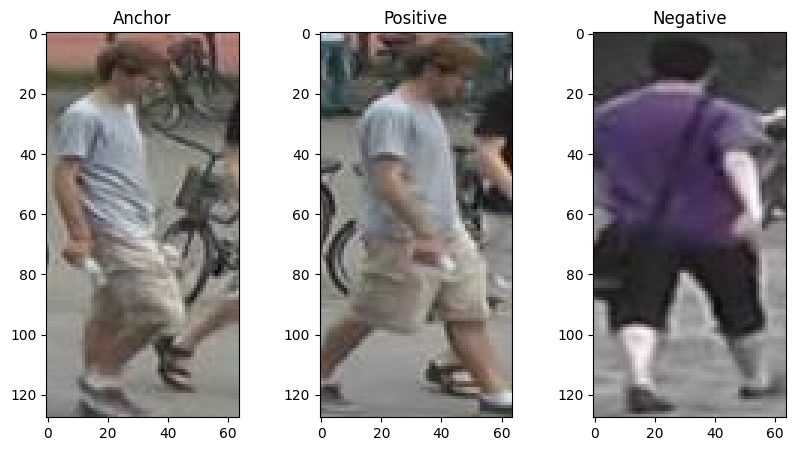

In [ ]:
# Plot images
idx = 33
A,P,N = trainset[idx]

f, (ax1, ax2, ax3) = plt.subplots(1,3,figsize= (10,5))

ax1.set_title('Anchor')
ax1.imshow(A.numpy().transpose((1,2,0)), cmap = 'gray')

ax2.set_title('Positive')
ax2.imshow(P.numpy().transpose((1,2,0)), cmap = 'gray')

ax3.set_title('Negative')
ax3.imshow(N.numpy().transpose((1,2,0)), cmap = 'gray')

# Load Dataset into Batches

In [ ]:
trainloader = DataLoader(trainset, batch_size = batch_size, shuffle = True)
validloader = DataLoader(validset, batch_size = batch_size)

In [ ]:
print(f"No. of batches in trainloader : {len(trainloader)}") # total trainset / batch_size = 3200/32 = 100
print(f"No. of batches in validloader : {len(validloader)}") # total validset / batch_size = 800/32 = 25

No. of batches in trainloader : 100
No. of batches in validloader : 25


In [ ]:
for A,P,N in trainloader:
  break;

print(f"One image batch shape : {A.shape}")

 # 32- no. of imgs in one batch
 # 3 - no. of channel (RGB color)
 # 128x64 - heigth x width of an img

One image batch shape : torch.Size([32, 3, 128, 64])


# Create Model

In [ ]:
class APN_Model(nn.Module):
  def __init__(self, emb_size = 512):
    super(APN_Model , self).__init__()

    self.efficient = timm.create_model('efficientnet_b0', pretrained = True)
    self.efficient.classifier = nn.Linear(in_features=self.efficient.classifier.in_features, out_features=emb_size)

  def forward(self, images):

    embeddings = self.efficient(images)

    return embeddings

In [ ]:
model = APN_Model()
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

APN_Model(
  (efficient): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Co

# Create Train and Eval function

In [ ]:
def train_fn(model, DataLoader, optimizer, criterion):
  model.train() # ON dropout
  total_loss = 0.0

  for A,P,N in tqdm(DataLoader):
     A,P,N = A.to(device), P.to(device), N.to(device)

     A_embs = model(A)
     P_embs = model(P)
     N_embs = model(N)

     loss = criterion(A_embs, P_embs, N_embs)


     optimizer.zero_grad()
     loss.backward()
     optimizer.step()

     total_loss += loss.item()
  return total_loss / len(DataLoader)



In [ ]:
def eval_fn(model, DataLoader, criterion):
  model.eval() # OFF dropout
  total_loss = 0.0

  with torch.no_grad(): # disable gradient calculation.
     for A,P,N in tqdm(DataLoader):
         A,P,N = A.to(device), P.to(device), N.to(device)

         A_embs = model(A)
         P_embs = model(P)
         N_embs = model(N)

         loss = criterion(A_embs, P_embs, N_embs)
         total_loss += loss.item()
     return total_loss / len(DataLoader)


In [ ]:
criterion = nn.TripletMarginLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = lr)


# Create Training Loop

In [ ]:
best_valid_loss = np.inf

for i in range(epochs):
  train_loss = train_fn(model, trainloader, optimizer, criterion)
  valid_loss = eval_fn(model, validloader, criterion)

  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), 'best_model.pt')
    print("saved_weight_success")

    print(f"Epoch : {i+1} train_loss: {train_loss}  valid_loss: {valid_loss}")

100%|██████████| 25/25 [00:02<00:00,  9.23it/s]


saved_weight_success
Epoch : 1 train_loss: 0.5449448399245739  valid_loss: 0.5337234491109848


100%|██████████| 25/25 [00:02<00:00,  9.37it/s]


saved_weight_success
Epoch : 2 train_loss: 0.29089276254177093  valid_loss: 0.33288648128509524


100%|██████████| 25/25 [00:02<00:00,  8.53it/s]


...

100%|██████████| 25/25 [00:02<00:00,  9.34it/s]


saved_weight_success
Epoch : 11 train_loss: 0.064369213655591  valid_loss: 0.1181424966454506


100%|██████████| 25/25 [00:02<00:00,  9.30it/s]


saved_weight_success
Epoch : 14 train_loss: 0.026935200244188308  valid_loss: 0.11328105628490448


100%|██████████| 25/25 [00:02<00:00,  8.78it/s]


# Get Anchor Embeddings

In [ ]:
def get_encoding_csv(model,anc_img_names):
  anc_img_names_arr = np.array(anc_img_names)
  encodings = []

  model.eval()
  with torch.no_grad():
    for i in tqdm(anc_img_names_arr):
      A = io.imread(data_dir + i)
      A = torch.from_numpy(A).permute(2,0,1)/255.0
      A = A.to(device)
      A_enc = model(A.unsqueeze(0)) # (channel x width x height)[3D input] --> (batchsize(1) x channel x width x height)[4D input]
      encodings.append(A_enc.squeeze().cpu().detach().numpy()) # numpy doesn't support cuda --> convert to cpu


    encodings = np.array(encodings)
    encodings = pd.DataFrame(encodings)
    df_enc = pd.concat([anc_img_names, encodings], axis = 1)

  return df_enc


In [ ]:
model.load_state_dict(torch.load('best_model.pt'))
df_enc = get_encoding_csv(model, df['Anchor'])

100%|██████████| 4000/4000 [00:58<00:00, 67.91it/s]


In [ ]:
df_enc.to_csv('anchor_encodings.csv', index = False)
df_enc.head()

,Anchor,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,1420_c5s3_052165_01.jpg,-0.549020,-0.158919,-0.436617,-0.365196,0.131418,0.110342,-0.108792,-0.193297,0.163486,...,-1.039899,-0.067394,-0.236491,-0.205026,0.432205,-0.066466,0.437242,0.043044,-0.324574,-0.173218
1,1420_c3s3_061978_03.jpg,-0.579573,-0.394399,-0.504974,-0.257228,-0.031490,0.041796,-0.038127,-0.045574,0.236696,...,-0.946777,-0.044789,-0.238353,-0.298323,0.199541,0.126137,0.283155,-0.074956,-0.252554,-0.364837
2,1420_c5s3_062565_05.jpg,-0.498977,-0.232896,-0.338269,-0.248124,-0.156064,0.028885,-0.038724,-0.004749,0.290550,...,-0.754898,-0.167443,-0.262996,-0.107255,0.380868,-0.071261,0.385771,-0.095651,-0.449535,-0.169263
3,1420_c6s3_085592_04.jpg,-0.522386,0.026362,-0.278217,-0.388679,-0.070191,-0.149374,-0.027678,-0.137394,0.644575,...,-0.786364,0.070640,-0.351082,0.084221,0.092137,-0.284591,0.327615,0.059209,-0.784411,-0.039595
4,0663_c5s3_085987_03.jpg,-0.140893,0.457198,0.859134,0.513189,0.378703,0.069714,-0.005013,0.743207,0.569826,...,0.550440,0.131474,-0.336326,-0.104998,0.361923,0.236289,0.456691,-0.986252,-0.516205,-0.009343


# Inference

In [ ]:
def eucledian_dist(img_enc, anc_enc_arr):
   dist = np.sqrt(np.dot(img_enc - anc_enc_arr, (img_enc - anc_enc_arr).T))
   return dist

In [ ]:
# To get encodings for a specific img
idx = 90 # defining the Query image
img_name = df_enc['Anchor'].iloc[idx]
img_path = data_dir + img_name

img = io.imread(img_path)
img = torch.from_numpy(img).permute(2,0,1)/255.0

model.eval()
with torch.no_grad():
  img_enc = model(img.unsqueeze(0).to(device))
  img_enc = img_enc.cpu().detach().numpy()

In [ ]:
anc_enc_arr = df_enc.iloc[:,1:].to_numpy()
anc_img_names = df_enc['Anchor']

In [ ]:
distance = []

for i in range(anc_enc_arr.shape[0]):
  dist = eucledian_dist(img_enc, anc_enc_arr[i : i+1, :1])
  distance = np.append(distance,dist)

In [ ]:
closest_idx = np.argsort(distance)


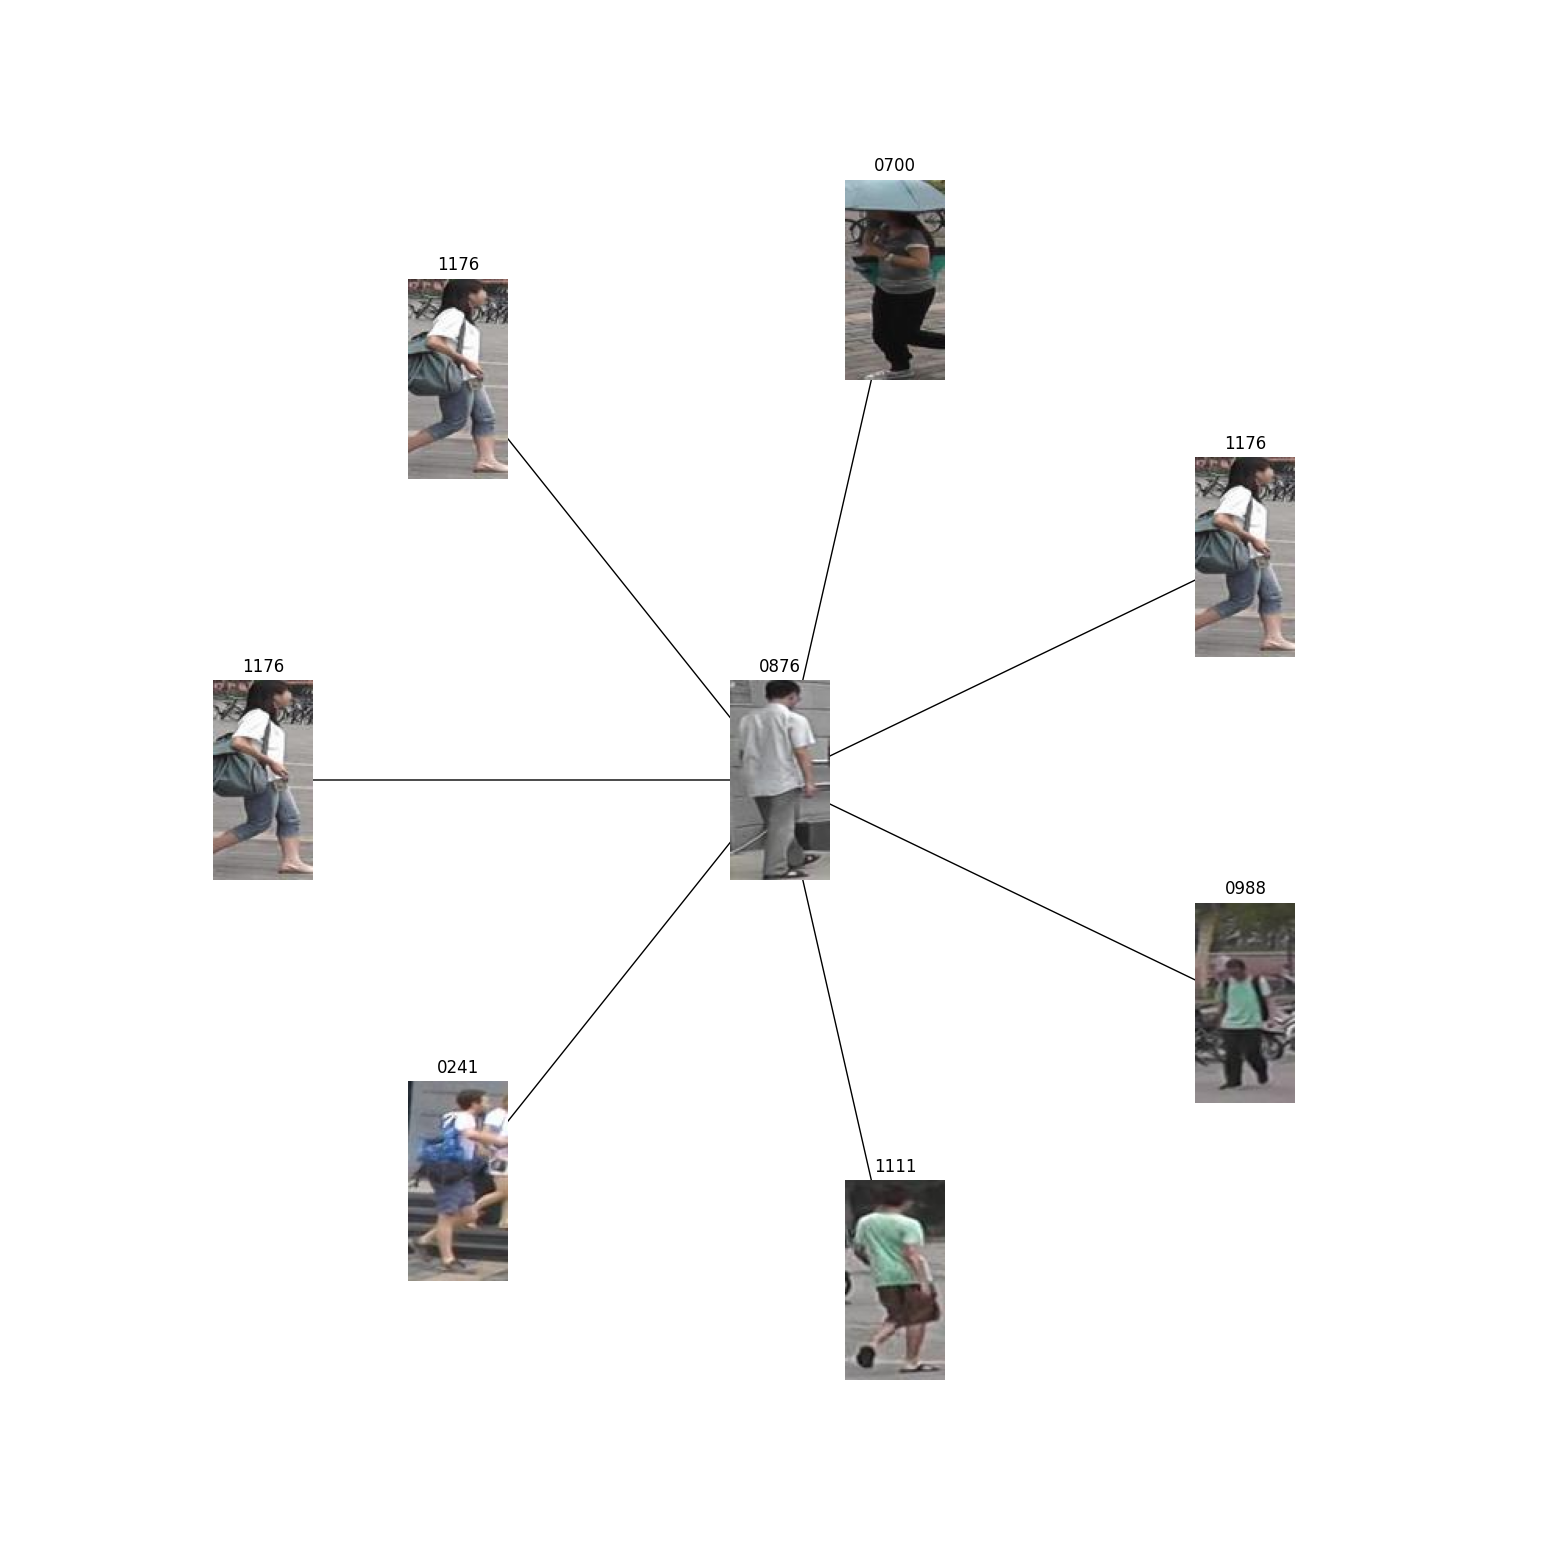

In [ ]:
from utils import plot_closest_imgs

plot_closest_imgs(anc_img_names, data_dir, img, img_path, closest_idx, distance, no_of_closest = 7);